<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/nprivaul/fractionalpdes/blob/master/comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

This code solves the $1$D time-fractional F-KPP equation 
 
$$\partial_t^\alpha u=-(-\Delta u)^{\gamma/2}-\lambda u+\lambda (p_0+p_1 u + \cdots + p_N u^N)$$  
 on $\mathbb{R}$ with initial condition $f$, $\lambda>0$, $p_k\in [0,1]$, and $p_0+\cdots +p_N=$, 
 first by MC estimation and then using a $L^1$ finite difference scheme in dimension $1$ with $\alpha = 0.5$ and $\gamma=2$.

In [1]:
import math
import matplotlib.pyplot as plt
from scipy.stats import expon,uniform,norm
import numpy as np

from scipy.linalg import solve_banded
import scipy.special 

plt.rcParams.update({
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,
    "figure.titlesize": 24,
    "xtick.major.pad": 8,        # Increase distance between x-axis and tick labels (default ~4)
    "axes.xmargin": 0,      # Equivalent to ax.margins(x=0)
    "figure.autolayout": True,  # Equivalent to plt.tight_layout()
})

Using 8 CPU cores for 101 points...
Progress: 1/101
Progress: 2/101
Progress: 3/101
Progress: 4/101
Progress: 5/101
Progress: 6/101
Progress: 7/101
Progress: 8/101
Progress: 9/101
Progress: 10/101
Progress: 11/101
Progress: 12/101
Progress: 13/101
Progress: 14/101
Progress: 15/101
Progress: 16/101
Progress: 17/101
Progress: 18/101
Progress: 19/101
Progress: 20/101
Progress: 21/101
Progress: 22/101
Progress: 23/101
Progress: 24/101
Progress: 25/101
Progress: 26/101
Progress: 27/101
Progress: 28/101
Progress: 29/101
Progress: 30/101
Progress: 31/101
Progress: 32/101
Progress: 33/101
Progress: 34/101
Progress: 35/101
Progress: 36/101
Progress: 37/101
Progress: 38/101
Progress: 39/101
Progress: 40/101
Progress: 41/101
Progress: 42/101
Progress: 43/101
Progress: 44/101
Progress: 45/101
Progress: 46/101
Progress: 47/101
Progress: 48/101
Progress: 49/101
Progress: 50/101
Progress: 51/101
Progress: 52/101
Progress: 53/101
Progress: 54/101
Progress: 55/101
Progress: 56/101
Progress: 57/101
Prog

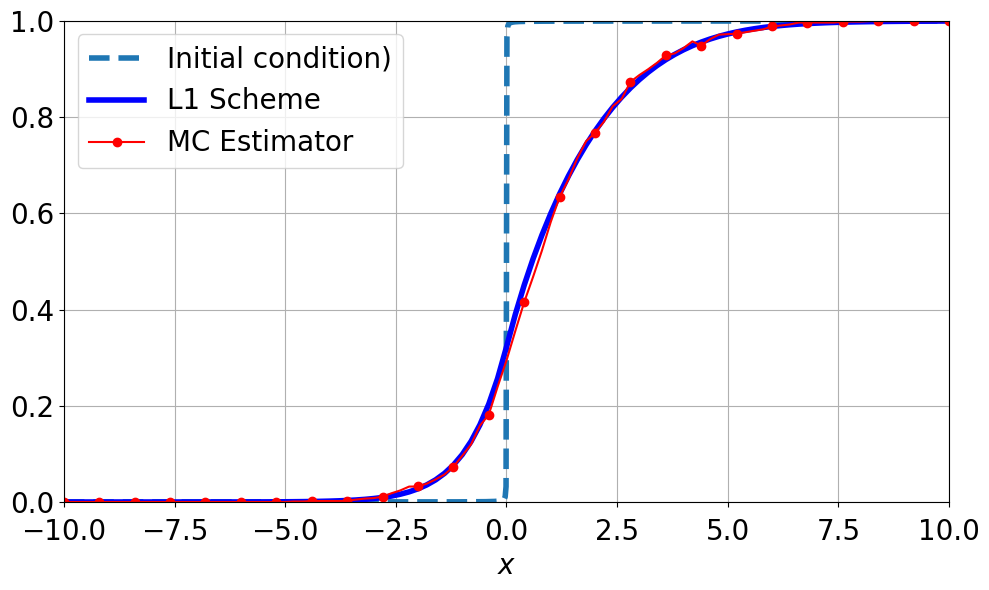

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Sun Mar 15 20:50:57 2026

@author: gerar
"""

#=============================================================================
#MC ALGORITHM
#=============================================================================
def f(x,d): 
    """
    Initial condition - a function from R^d to [0,1]
    x=[x[1],...,x[d]] is an array if d>1; if d=1, x must be a float
    """
    if d==1:
        return 1*(0.5+np.arctan(1000*x)/np.pi)  
    else:
        # For 2D/3D, use radially symmetric initial condition
        r_squared = sum(x_i**2 for x_i in x)
        return 0.5 + np.arctan(1000 * (1 - np.sqrt(r_squared))) / np.pi
    
def subordinator_rv(alpha):
    """
    This simulates S(1), where (S(t))_T is an \alpha-stable subordinator (Chambers, Mallows, Stuck (1976))
    alpha is a number in (0,1]
    """
    if alpha==1:
        return 1
    else:
        theta=math.pi*uniform.rvs()
        w=expon.rvs()
        aux1=(math.sin((1-alpha)*theta)/w)**((1-alpha)/alpha)
        aux2=math.sin(alpha*theta)/math.sin(theta)**(1/alpha)
        return aux1*aux2
    
def stable_rv(gamma,d,t):
    """
    This simulates X(t), where (X(t))_t is a d-dimensional symmetric gamma-stable process
    gamma is a number in (0,2], d is a natural number, tgeq 0
    If d==1, the output is a float; if d>1, it is an array 
    """
    if d==1:
        return norm.rvs()*(2*subordinator_rv(gamma/2))**(1/2)*t**(1/gamma)  #Scaling property
    else:
       aux1=norm.rvs(size=d)
       aux2=subordinator_rv(gamma/2)
       return [aux1[i]*(2*aux2)**(1/2)*t**(1/gamma) for i in range(d)]

def discrete_rv(p):
    """
    This simulates a random variable on {0,1,..., N}, N>1, according to law [p_0,p_1,...,p_N]
    p_k is a number in [0,1] and p_0+p_1+...+p_N=1
    """
    aux=0
    u=uniform.rvs()
    for i in range(len(p)):
        if u<aux+p[i]:
            return i
        else:
            aux=aux+p[i]
    
def branching(alpha,gamma,lam,p,d,x,T):
    """
    This simulates the random variable V=prod_{k in mathcal{N}_t^\alpha}f(x+Y_k^\alpha(t))
    alpha,gam,lam,p,d are as in the section "PARAMETERS"
    x=[x[1],...,x[d]] is an array representing a point, T is a positive number representing time
    """
    s1=subordinator_rv(alpha)
    tau=expon.rvs()/lam                             #Exponential lifetime 
    sigma=s1*tau**(1/alpha)                         #Mittag Leffler lifetime
    if sigma>T:                                     #No branching case
        et=(T/s1)**alpha                            #Inverse stable subordinator law
        dx=stable_rv(gamma,d,et)                    #Spatial displacement
        if d==1:                                    #Dimension one case
            Y=x+dx                                  #Position at branching time
            return f(Y,d)
        else:                                       #Dimension greater than one
            Y=[x[i]+dx[i] for i in range(d)]
            return f(Y,d)
    else:                                           #Branching case
        branches=discrete_rv(p)                     #Number of branches
        aux=1
        dx=stable_rv(gamma,d,tau)                   
        if d==1:
            Y=x+dx
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma)    #Recursion
            return aux 
        else:
            Y=[x[i]+dx[i] for i in range(d)]
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma) 
            return aux
            
def mc_kpp_sol(alpha,gamma,lam,p,d,x,T,n_iter):           
    """
    This is the Monte Carlo estimator of the solution at (x,T)
    alpha,gam,lam,p,d are as in the section "Parameters"
    n_iter is the sample size
    """       
    aux=0
    for i in range(n_iter):
        aux=aux+branching(alpha,gamma,lam,p,d,x,T)
    return aux/n_iter               #MC estimator

#==============================================================================
#SIMULATION VIA MC ALGORITHM 1D, gamma=2
#==============================================================================
#Parameters
alpha=0.5   #time-fractional order alpha - a number in (0,1]
gamma=2     #space-fractional order gamma - a number in (0,2]
lam=1       #\lambda - a strictly positive constant
p=[0,0,1]   #probability density [p_0,p_1,...,p_N] corresponding to the polynomial non-linearity - it satisfies p_k in[0,1] and p_0+p_1+...+p_N=1
d=1         #dimension - a natural number
T=1         #time - a positive number
n_iter=1000  #sample size for Monte Carlo estimator - a natural number (reduced for speed)
a=-10       #Interval [a,b] for x
b=10
nx1=101     #Number of points in [a,b]

x_1d = [a+i*(b-a)/(nx1-1) for i in range(nx1)]    #Space discretization

#MC solution
#y_1d = [0 for i in range(nx1)]
#for i in range(nx1):
#    y_1d[i]=mc_kpp_sol(alpha,gamma,lam,p,d,x_1d[i],T,n_iter)
#    print(f"Progress: {i+1}/{nx1}")   
from multiprocessing import Pool, cpu_count

def worker(i):
    return i, mc_kpp_sol(alpha, gamma, lam, p, d, x_1d[i], T, n_iter)

if __name__ == "__main__":

    y_1d = [None] * nx1

    print(f"Using {cpu_count()} CPU cores for {nx1} points...")

    with Pool(cpu_count()) as pool:
        for k, (i, val) in enumerate(pool.imap(worker, range(nx1)), 1):
            y_1d[i] = val
            print(f"Progress: {k}/{nx1}")

    y_1d = np.array(y_1d)

    
#==============================================================================
#SIMULATION VIA L1 FINITE DIFFERENCE SCHEME 1D, gamma=2
#==============================================================================
#Parameters for L1 scheme and Monte Carlo
alpha = 0.5             # fractional order -  alpha in (0,1)
L = 10                 # interval [-L,L] for simulation - L>0
nx = 101                # number of spatial grid points - a natural number
nt = 101                # number of time steps - a natural number
t_final = 1           # time - t>0
dx = 2 * L / (nx-1)     
dt = t_final / nt       
x_values = np.linspace(-L, L, nx)   #space discretization
x_ic_values = np.linspace(-L, L, 10*nx)   #space discretization
u = np.zeros((nt+1, nx))            # solution

# Define initial condition 
def phi(x):
    return 1*(0.5+np.arctan(1000*x)/np.pi)

u[0, :] = phi(x_values)    # Initial condition

# Define source terms
def g(x):
    return 0

# Implementation of L1 scheme

# Define L1 Caputo derivative weights
b = np.zeros(nt+1)
for k in range(1, nt+1):
    b[k] = (k**(1-alpha) - (k-1)**(1-alpha))
b = b / scipy.special.gamma(2-alpha)

r = 1.0 / dx**2 # 1.0 Laplacian operator

# Implementation of finite difference in space (second order centre difference)
# Define tridiagonal matrix A

# Create banded matrix for (c0/dt^alpha)
c0 = b[1]
main = (c0/(dt**alpha) + 2*r) * np.ones(nx-2)
lower = (-r) * np.ones(nx-3)
upper = (-r) * np.ones(nx-3)
ab = np.zeros((3, nx-2))
ab[0, 1:] = upper
ab[1, :] = main
ab[2, :-1] = lower

for n in range(nt):
    hist = np.zeros(nx-2)
    
    # history yerm: sum_{k=1...n} b[k+1]*(u^{n+1-k} - u^{n-k})
    for k in range(1, n+1):
        hist += b[k+1] * (u[n+1-k, 1:-1] - u[n-k, 1:-1])

    rhs = (c0/(dt ** alpha)) * u[n, 1:-1] - (1.0/(dt ** alpha)) * hist + u[n, 1:-1]**2 - u[n, 1:-1] + g(x_values[1:-1])
    # Apply boundary conditions at each time step
    # Since the Laplacian stencil uses neighboring points, add effect of boundaries
    rhs[0] += r * phi(x_values[0])  # Left boundary u[*, 0] = 4
    rhs[-1] += r * phi(x_values[-1]) # Right boundary u[*, -1] = 4

    u[n+1, 0] = phi(x_values[0])   # u(-L, t)
    u[n+1, -1] = phi(x_values[-1])  # u(L, t)
    u[n+1, 1:-1] = solve_banded((1, 1), ab, rhs)
    
#==============================================================================
#COMPARISON MC ALGORITHM VS FINITE DIFFERENCE METHOD 1D, gamma=2
#==============================================================================
#Error
error = np.abs(u[-1] - y_1d)
print(f"Max pointwise error: {np.max(error):.6e}")

# Plot solution curves with initial condition
#plt.figure(figsize=(10, 6))
#plt.plot(x_values, u[-1], 'r-', label='L1 scheme',linewidth=2)
#plt.plot(x_1d, y_1d, 'b--', label='MC estimator',linewidth=2)
#plt.plot(x_values, phi(x_values), 'g-', label='Initial condition',linewidth=2)
#plt.legend()
#plt.xlabel(r"$x$")
#plt.ylim(-0.001,1.001)
#plt.grid(True, alpha=0.3)
#plt.savefig(f'comparison_t_{T}.png', format='png', dpi=150)
#plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_ic_values, phi(x_ic_values),label='Initial condition)',linestyle='--',lw=4)
ax.plot(x_values, u[-1], label='L1 Scheme', linestyle='-',color='blue',markersize=10,lw=4)
ax.plot(x_1d, y_1d, label='MC Estimator', linestyle='-',marker='.',color='red',markersize=12,markevery=4,lw=1.5)
ax.set_xlabel(r"$x$")
ax.margins(x=0)
ax.legend(loc="upper left", fontsize=20)
ax.set_ylim(-0.001, 1.001)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig(f'comparison_t_{T}.pdf', bbox_inches="tight")

Using 8 CPU cores for 101 points...
Progress: 1/101
Progress: 2/101
Progress: 3/101
Progress: 4/101
Progress: 5/101
Progress: 6/101
Progress: 7/101
Progress: 8/101
Progress: 9/101
Progress: 10/101
Progress: 11/101
Progress: 12/101
Progress: 13/101
Progress: 14/101
Progress: 15/101
Progress: 16/101
Progress: 17/101
Progress: 18/101
Progress: 19/101
Progress: 20/101
Progress: 21/101
Progress: 22/101
Progress: 23/101
Progress: 24/101
Progress: 25/101
Progress: 26/101
Progress: 27/101
Progress: 28/101
Progress: 29/101
Progress: 30/101
Progress: 31/101
Progress: 32/101
Progress: 33/101
Progress: 34/101
Progress: 35/101
Progress: 36/101
Progress: 37/101
Progress: 38/101
Progress: 39/101
Progress: 40/101
Progress: 41/101
Progress: 42/101
Progress: 43/101
Progress: 44/101
Progress: 45/101
Progress: 46/101
Progress: 47/101
Progress: 48/101
Progress: 49/101
Progress: 50/101
Progress: 51/101
Progress: 52/101
Progress: 53/101
Progress: 54/101
Progress: 55/101
Progress: 56/101
Progress: 57/101
Prog

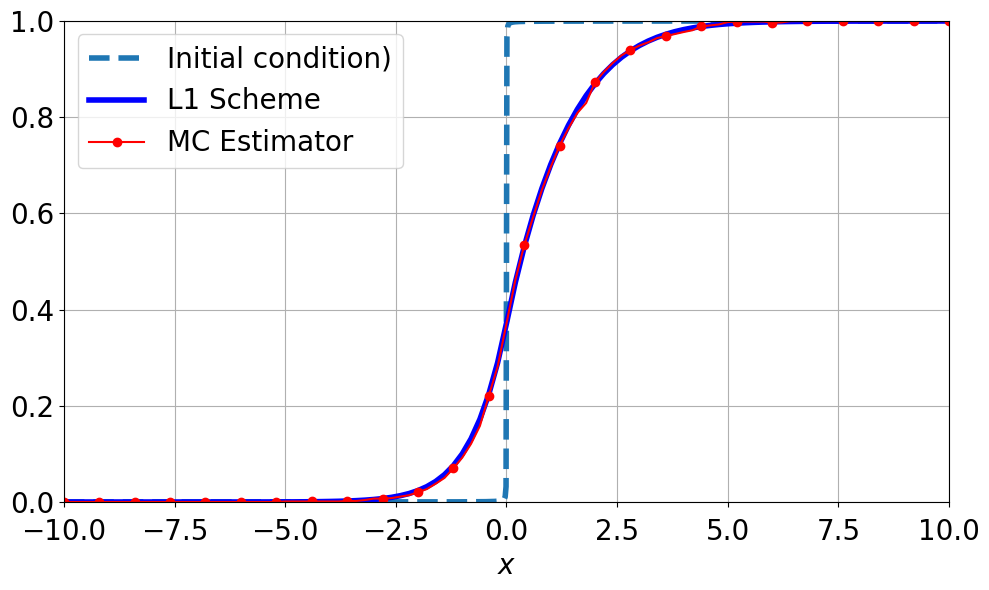

In [3]:
#==============================================================================
#SIMULATION VIA MC ALGORITHM 1D, gamma=2
#==============================================================================
#Parameters
alpha=0.5   #time-fractional order alpha - a number in (0,1]
gamma=2     #space-fractional order gamma - a number in (0,2]
lam=1       #\lambda - a strictly positive constant
p=[0,0,1]   #probability density [p_0,p_1,...,p_N] corresponding to the polynomial non-linearity - it satisfies p_k in[0,1] and p_0+p_1+...+p_N=1
d=1         #dimension - a natural number
T=0.5        #time - a positive number
n_iter=1000  #sample size for Monte Carlo estimator - a natural number (reduced for speed)
a=-10       #Interval [a,b] for x
b=10
nx1=101     #Number of points in [a,b]

x_1d = [a+i*(b-a)/(nx1-1) for i in range(nx1)]    #Space discretization

#MC solution
#y_1d = [0 for i in range(nx1)]
#for i in range(nx1):
#    y_1d[i]=mc_kpp_sol(alpha,gamma,lam,p,d,x_1d[i],T,n_iter)
#    print(f"Progress: {i+1}/{nx1}")
from multiprocessing import Pool, cpu_count

def worker(i):
    return i, mc_kpp_sol(alpha, gamma, lam, p, d, x_1d[i], T, n_iter)

if __name__ == "__main__":

    y_1d = [None] * nx1

    print(f"Using {cpu_count()} CPU cores for {nx1} points...")

    with Pool(cpu_count()) as pool:
        for k, (i, val) in enumerate(pool.imap(worker, range(nx1)), 1):
            y_1d[i] = val
            print(f"Progress: {k}/{nx1}")

    y_1d = np.array(y_1d)
    

#==============================================================================
#SIMULATION VIA L1 FINITE DIFFERENCE SCHEME 1D, gamma=2
#==============================================================================
#Parameters for L1 scheme and Monte Carlo
alpha = 0.5             # fractional order -  alpha in (0,1)
L = 10                 # interval [-L,L] for simulation - L>0
nx = 101                # number of spatial grid points - a natural number
nt = 101                # number of time steps - a natural number
t_final = 0.5           # time - t>0
dx = 2 * L / (nx-1)     
dt = t_final / nt       
x_values = np.linspace(-L, L, nx)   #space discretization
u = np.zeros((nt+1, nx))            # solution

# Define initial condition 
def phi(x):
    return 1*(0.5+np.arctan(1000*x)/np.pi)

u[0, :] = phi(x_values)    # Initial condition

# Define source terms
def g(x):
    return 0

# Implementation of L1 scheme

# Define L1 Caputo derivative weights
b = np.zeros(nt+1)
for k in range(1, nt+1):
    b[k] = (k**(1-alpha) - (k-1)**(1-alpha))
b = b / scipy.special.gamma(2-alpha)

r = 1.0 / dx**2 # 1.0 Laplacian operator

# Implementation of finite difference in space (second order centre difference)
# Define tridiagonal matrix A

# Create banded matrix for (c0/dt^alpha)
c0 = b[1]
main = (c0/(dt**alpha) + 2*r) * np.ones(nx-2)
lower = (-r) * np.ones(nx-3)
upper = (-r) * np.ones(nx-3)
ab = np.zeros((3, nx-2))
ab[0, 1:] = upper
ab[1, :] = main
ab[2, :-1] = lower

for n in range(nt):
    hist = np.zeros(nx-2)
    
    # history yerm: sum_{k=1...n} b[k+1]*(u^{n+1-k} - u^{n-k})
    for k in range(1, n+1):
        hist += b[k+1] * (u[n+1-k, 1:-1] - u[n-k, 1:-1])

    rhs = (c0/(dt ** alpha)) * u[n, 1:-1] - (1.0/(dt ** alpha)) * hist + u[n, 1:-1]**2 - u[n, 1:-1] + g(x_values[1:-1])
    # Apply boundary conditions at each time step
    # Since the Laplacian stencil uses neighboring points, add effect of boundaries
    rhs[0] += r * phi(x_values[0])  # Left boundary u[*, 0] = 4
    rhs[-1] += r * phi(x_values[-1]) # Right boundary u[*, -1] = 4

    u[n+1, 0] = phi(x_values[0])   # u(-L, t)
    u[n+1, -1] = phi(x_values[-1])  # u(L, t)
    u[n+1, 1:-1] = solve_banded((1, 1), ab, rhs)
    
#==============================================================================
#COMPARISON MC ALGORITHM VS FINITE DIFFERENCE METHOD 1D, gamma=2
#==============================================================================
#Error
error = np.abs(u[-1] - y_1d)
print(f"Max pointwise error: {np.max(error):.6e}")

# # Plot solution curves with initial condition
# plt.figure(figsize=(10, 6))
# plt.plot(x_values, u[-1], 'r-', label='L1 scheme',linewidth=2)
# plt.plot(x_1d, y_1d, 'b--', label='MC estimator',linewidth=2)
# plt.plot(x_values, phi(x_values), 'g-', label='Initial condition',linewidth=2)
# plt.legend()
# plt.xlabel(r"$x$")
# # plt.ylabel(r"$v(t,x)$")
# # plt.title(f'Solution of Time-Fractional F-KPP Equation at t={t_final}')
# #plt.xlim(-2, 2)
# plt.ylim(-0.001,1.001)
# plt.grid(True, alpha=0.3)
# plt.savefig(f'comparison_t_{T}.png', format='png', dpi=150)
# plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_ic_values, phi(x_ic_values),label='Initial condition)',linestyle='--',lw=4)
ax.plot(x_values, u[-1], label='L1 Scheme', linestyle='-',color='blue',markersize=10,lw=4)
ax.plot(x_1d, y_1d, label='MC Estimator', linestyle='-',marker='.',color='red',markersize=12,markevery=4,lw=1.5)
ax.set_xlabel(r"$x$")
ax.margins(x=0)
ax.legend(loc="upper left", fontsize=20)
ax.set_ylim(-0.001, 1.001)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig(f'comparison_t_{T}.pdf', bbox_inches="tight")
